# Librerías

In [2]:
import pandas as pd
import io
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de Pearson

REPORTE ESTADÍSTICO: CORRELACIÓN DE PEARSON Y P-VALUE
Membresía  r_Pearson  R_cuadrada  p_value
    %1MES    -0.7835      0.6138    0.000
  %3MESES    -0.1741      0.0303    0.001
  %6MESES     0.3538      0.1252    0.000
 %12MESES     0.6619      0.4382    0.000


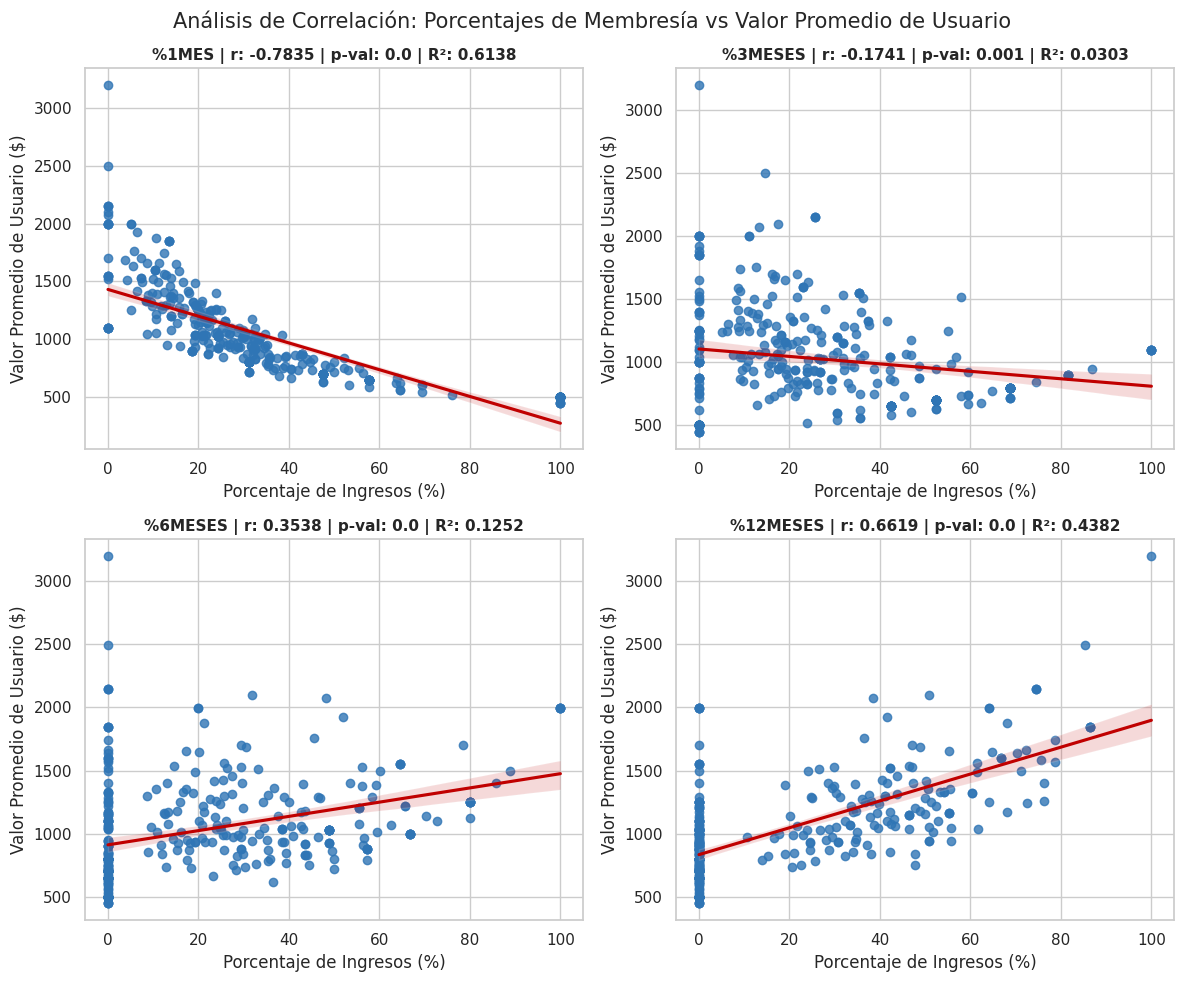

In [6]:
datos_crudos = """Día	Usuarios totales	Ingreso diario	Valor promedio de usuario diario	%1MES	%3MESES	%6MESES	%12MESES
01-ene	17	12764.7	750.8647059	38.70126207	38.74356624	0	22.55517168
02-ene	23	18969.3	824.7521739	35.51264411	20.85685819	28.45281587	15.17768183
03-ene	27	23465.7	869.1	30.62171595	29.50561884	15.33387029	24.53879492
04-ene	8	4942.8	617.85	63.60160233	0	36.39839767	0
05-ene	9	14031.9	1559.1	12.80225771	0	25.64299917	61.55474312
06-ene	5	5215.5	1043.1	8.610871441	56.89387403	34.49525453	0
07-ene	3	1887.3	629.1	47.59179781	52.40820219	0	0
08-ene	10	9351	935.1	28.81616939	21.15495669	19.23965351	30.7892204
09-ene	10	9351	935.1	28.81616939	21.15495669	19.23965351	30.7892204
10-ene	6	5664.6	944.1	15.85637115	52.38322212	31.76040674	0
11-ene	8	7372.8	921.6	24.36523438	26.83105469	48.80371094	0
12-ene	6	7554.6	1259.1	11.88944484	26.1853705	23.8146295	38.11055516
13-ene	8	6022.8	752.85	52.19665272	0	0	47.80334728
14-ene	28	27154.8	969.8142857	24.80776879	18.21224977	46.37743603	10.60254541
15-ene	26	20586.6	791.7923077	34.90425811	33.63207135	17.47835971	13.98531083
16-ene	24	20498.4	854.1	39.43624868	9.650509308	8.776782578	42.13645943
17-ene	8	5752.8	719.1	31.22653317	68.77346683	0	0
18-ene	9	8361.9	929.1	32.22473361	11.82865138	21.51544505	34.43116995
19-ene	6	5664.6	944.1	31.71274229	17.46107404	0	50.82618367
20-ene	5	7105.5	1421.1	6.320455985	27.84040532	25.31982267	40.51931602
21-ene	11	11150.1	1013.645455	32.22213254	0	16.1352813	51.64258617
22-ene	13	18258.3	1404.484615	12.29851629	10.83452457	29.56080248	47.30615665
23-ene	7	4763.7	680.5285714	37.71018326	62.28981674	0	0
24-ene	11	15200.1	1381.827273	8.863757475	13.01438806	59.18053171	18.94132275
25-ene	6	4584.6	764.1	39.18335296	21.57440126	39.24224578	0
26-ene	6	3234.6	539.1	69.42125765	30.57874235	0	0
27-ene	4	2336.4	584.1	57.66563945	42.33436055	0	0
28-ene	19	13932.9	733.3105263	45.12628383	21.29707383	12.91260255	20.66403979
29-ene	7	8273.7	1181.957143	21.71217231	0	43.48961166	34.79821603
30-ene	25	23377.5	935.1	26.89509143	25.38594803	23.08758422	24.63137632
31-ene	28	27694.8	989.1	21.08085272	32.14285714	25.98466138	20.79162875
01-feb	20	19280	964	28.46991701	34.20124481	20.73651452	16.59232365
02-feb	14	16286	1163.285714	21.44786934	26.9925089	12.27434606	39.2852757
03-feb	8	6692	836.5	52.19665272	0	0	47.80334728
04-feb	6	7794	1299	19.20708237	14.1005902	25.64793431	41.04439312
05-feb	6	6894	1149	21.71453438	31.88279663	0	46.40266899
06-feb	3	2097	699	47.59179781	52.40820219	0	0
07-feb	3	2097	699	47.59179781	52.40820219	0	0
08-feb	5	6995	1399	14.26733381	0	85.73266619	0
09-feb	2	1598	799	31.22653317	68.77346683	0	0
10-feb	1	1999	1999	0	0	100	0
11-feb	7	10393	1484.714286	19.20523429	0	19.23409987	61.56066583
12-feb	8	9992	1249	24.96997598	10.99879904	0	64.03122498
13-feb	4	2596	649	57.66563945	42.33436055	0	0
14-feb	18	25482	1415.666667	17.62420532	8.62569657	23.53425948	50.21583863
15-feb	13	16087	1237.461538	21.71318456	13.66320632	24.85236526	39.77124386
16-feb	18	18282	1015.666667	30.02406739	24.04550924	10.93425227	34.9961711
17-feb	8	7892	986.5	18.96857577	55.70197669	25.32944754	0
18-feb	5	5795	1159	25.83261432	18.96462468	0	55.202761
19-feb	8	8192	1024	24.36523438	26.83105469	48.80371094	0
20-feb	2	3698	1849	13.49378042	0	0	86.50621958
21-feb	2	998	499	100	0	0	0
22-feb	3	2697	899	18.5020393	81.4979607	0	0
23-feb	4	2596	649	57.66563945	42.33436055	0	0
24-feb	5	5195	1039	19.2107796	42.30991338	38.47930703	0
25-feb	1	499	499	100	0	0	0
26-feb	7	7693	1099	32.43208111	0	25.98466138	41.58325751
27-feb	8	9992	1249	4.993995196	54.9939952	40.01200961	0
28-feb	18	15282	849	35.91807355	43.14880251	0	20.93312394
01-mar	9	13791	1532.333333	7.236603582	31.87586107	14.49496048	46.39257487
02-mar	11	10589	962.6363636	32.98706205	10.37869487	56.63424308	0
03-mar	13	9487	729.7692308	42.07863392	57.92136608	0	0
04-mar	3	2697	899	18.5020393	81.4979607	0	0
05-mar	2	1598	799	31.22653317	68.77346683	0	0
06-mar	4	4096	1024	24.36523438	26.83105469	48.80371094	0
07-mar	4	1996	499	100	0	0	0
08-mar	5	3095	619	64.4911147	35.5088853	0	0
09-mar	2	2498	1249	19.97598078	0	80.02401922	0
10-mar	2	998	499	100	0	0	0
11-mar	5	4595	919	32.5788901	23.91730141	43.50380849	0
13-mar	4	3496	874	42.82036613	0	57.17963387	0
14-mar	12	11088	924	22.50180375	59.46969697	18.02849928	0
15-mar	16	22384	1399	17.83416726	0	53.58291637	28.58291637
16-mar	8	12092	1511.5	4.126695336	36.35461462	33.06318227	26.45550777
17-mar	3	2097	699	47.59179781	52.40820219	0	0
18-mar	5	5195	1039	19.2107796	42.30991338	38.47930703	0
19-mar	4	3496	874	42.82036613	0	57.17963387	0
20-mar	4	7696	1924	6.483887734	0	51.94906445	41.56704782
21-mar	2	1598	799	31.22653317	68.77346683	0	0
22-mar	4	3196	799	31.22653317	68.77346683	0	0
23-mar	5	5495	1099	27.24294813	0	72.75705187	0
24-mar	3	2097	699	47.59179781	52.40820219	0	0
26-mar	4	2596	649	57.66563945	42.33436055	0	0
27-mar	2	4298	2149	0	25.57003257	0	74.42996743
28-mar	8	10892	1361.5	13.74403232	20.17994859	36.70583915	29.37017995
29-mar	4	4096	1024	24.36523438	26.83105469	48.80371094	0
30-mar	8	6092	761.5	49.14642154	18.04005253	32.81352594	0
31-mar	13	8587	660.5384615	63.92220799	12.79841621	23.2793758	0
01-abr	23	20049.3	871.7086957	33.5996768	19.73335727	17.94676123	28.7202047
02-abr	17	15464.7	909.6882353	31.94436362	19.18756911	11.63359134	37.23447594
03-abr	26	20316.6	781.4076923	35.36812262	29.21059626	35.42128112	0
04-abr	4	5306.4	1326.6	8.463364993	37.27951153	0	54.25712347
05-abr	7	7463.7	1066.242857	24.0684915	13.25214036	24.10466659	38.57470156
06-abr	5	4675.5	935.1	19.2107796	42.30991338	38.47930703	0
07-abr	4	5306.4	1326.6	8.463364993	37.27951153	0	54.25712347
08-abr	4	4226.4	1056.6	10.62606474	46.80579216	42.5681431	0
09-abr	9	7551.9	839.1	35.68108688	26.19473245	0	38.12418067
10-abr	7	9623.7	1374.814286	13.99981296	0	56.08341906	29.91676798
11-abr	2	1438.2	719.1	31.22653317	68.77346683	0	0
12-abr	5	4135.5	827.1	32.5788901	23.91730141	43.50380849	0
13-abr	4	1796.4	449.1	100	0	0	0
14-abr	21	21581.1	1027.671429	20.80987531	27.49906168	25.00938321	26.6816798
15-abr	16	19875.6	1242.225	22.59554429	4.976453541	0	72.42800217
16-abr	20	19512	975.6	27.6199262	15.20756458	27.66143911	29.51107011
17-abr	5	2245.5	449.1	100	0	0	0
18-abr	4	3686.4	921.6	24.36523438	26.83105469	48.80371094	0
19-abr	7	11783.7	1683.385714	3.811196823	16.78759643	30.5354006	48.86580616
20-abr	5	3325.5	665.1	40.51420839	59.48579161	0	0
21-abr	7	6383.7	911.9571429	28.14042013	15.49414916	56.36543071	0
22-abr	7	6113.7	873.3857143	22.03739143	48.53525688	29.42735169	0
23-abr	5	2785.5	557.1	64.4911147	35.5088853	0	0
24-abr	3	3777.3	1259.1	23.77888968	0	0	76.22111032
25-abr	1	449.1	449.1	100	0	0	0
26-abr	7	8543.7	1220.528571	10.51300959	34.73085431	21.05762141	33.6985147
27-abr	5	8185.5	1637.1	5.486531061	24.16712479	0	70.34634415
28-abr	27	30485.7	1129.1	19.15094618	19.46683199	23.60582175	37.77640008
29-abr	8	4132.8	516.6	76.06707317	23.93292683	0	0
30-abr	21	21851.1	1040.528571	26.71856337	9.053091149	24.70035833	39.52798715
01-may	8	10292	1286.5	19.39370385	10.67819666	38.8457054	31.08239409
02-may	9	9591	1065.666667	20.81117715	45.83463664	0	33.35418622
03-may	3	5997	1999	0	0	100	0
04-may	2	2498	1249	19.97598078	0	80.02401922	0
05-may	2	998	499	100	0	0	0
06-may	5	9995	1999	4.992496248	10.99549775	20	64.012006
07-may	2	1598	799	31.22653317	68.77346683	0	0
08-may	4	3496	874	42.82036613	0	57.17963387	0
09-may	2	3098	1549	0	35.47449968	64.52550032	0
10-may	3	3597	1199	13.87267167	30.55323881	55.57408952	0
11-may	4	2596	649	57.66563945	42.33436055	0	0
12-may	3	3597	1199	13.87267167	30.55323881	55.57408952	0
13-may	4	7396	1849	13.49378042	0	0	86.50621958
14-may	11	15389	1399	9.727727598	35.70732341	12.98979791	41.57515108
15-may	9	9291	1032.333333	21.48315574	35.48595415	43.03089011	0
16-may	11	9089	826.2727273	43.92122346	12.09153922	43.98723732	0
17-may	3	4797	1599	10.40233479	22.91015218	0	66.68751303
18-may	1	499	499	100	0	0	0
19-may	2	2498	1249	19.97598078	0	80.02401922	0
20-may	4	2596	649	57.66563945	42.33436055	0	0
21-may	4	2596	649	57.66563945	42.33436055	0	0
22-may	5	5195	1039	19.2107796	42.30991338	38.47930703	0
23-may	1	1099	1099	0	100	0	0
24-may	1	1999	1999	0	0	100	0
25-may	2	2498	1249	19.97598078	0	80.02401922	0
26-may	5	3995	799	49.96245307	0	50.03754693	0
27-may	2	2198	1099	0	100	0	0
28-may	9	6591	732.3333333	52.99651039	16.67425277	30.32923684	0
29-may	1	499	499	100	0	0	0
30-may	11	10289	935.3636364	29.09903781	32.04393041	38.85703178	0
31-may	13	16987	1306.692308	20.5627833	6.469653264	35.30346736	37.66409607
01-jun	16	12484	780.25	47.96539571	26.40980455	0	25.62479974
02-jun	10	15190	1519	9.855167874	21.70506912	26.31994733	42.11981567
03-jun	11	11489	1044.454545	34.74627905	9.565671512	0	55.68804944
04-jun	1	499	499	100	0	0	0
05-jun	3	4197	1399	23.77888968	0	0	76.22111032
06-jun	5	3695	739	40.51420839	59.48579161	0	0
07-jun	3	2697	899	18.5020393	81.4979607	0	0
08-jun	6	5694	949	26.29083246	38.60203723	35.10713031	0
10-jun	4	5296	1324	18.84441088	20.75151057	0	60.40407855
11-jun	1	499	499	100	0	0	0
12-jun	1	499	499	100	0	0	0
13-jun	3	4497	1499	11.09628641	0	88.90371359	0
14-jun	20	21080	1054	23.67172676	36.4943074	9.482922201	30.35104364
15-jun	18	23382	1299	12.80472158	37.60157386	8.549311436	41.04439312
16-jun	8	10592	1324	9.422205438	41.50302115	18.87273414	30.20203927
17-jun	1	1999	1999	0	0	100	0
18-jun	1	1099	1099	0	100	0	0
19-jun	3	2697	899	18.5020393	81.4979607	0	0
20-jun	4	8596	2149	0	25.57003257	0	74.42996743
21-jun	3	4797	1599	10.40233479	22.91015218	0	66.68751303
22-jun	1	499	499	100	0	0	0
23-jun	4	2596	649	57.66563945	42.33436055	0	0
24-jun	4	3196	799	31.22653317	68.77346683	0	0
25-jun	2	1598	799	31.22653317	68.77346683	0	0
26-jun	2	998	499	100	0	0	0
27-jun	4	1996	499	100	0	0	0
28-jun	18	19182	1065.666667	28.61536857	17.18798874	20.84245647	33.35418622
29-jun	2	3098	1549	0	35.47449968	64.52550032	0
30-jun	9	9591	1065.666667	26.01397143	11.45865916	62.52736941	0
01-jul	26	19506.6	750.2538462	36.83676294	35.49414044	27.66909661	0
02-jul	18	15103.8	839.1	29.73423907	39.29209868	11.91157192	19.06209033
03-jul	27	19685.7	729.1	36.50162301	45.22013441	18.27824258	0
04-jul	6	6204.6	1034.1	21.71453438	31.88279663	0	46.40266899
05-jul	4	3146.4	786.6	42.82036613	0	57.17963387	0
06-jul	8	5752.8	719.1	31.22653317	68.77346683	0	0
07-jul	3	1887.3	629.1	47.59179781	52.40820219	0	0
08-jul	4	3686.4	921.6	24.36523438	26.83105469	48.80371094	0
09-jul	9	11601.9	1289.1	11.61275308	17.0506555	46.52082848	24.81576294
10-jul	5	3595.5	719.1	49.96245307	0	50.03754693	0
11-jul	5	2785.5	557.1	64.4911147	35.5088853	0	0
12-jul	5	6565.5	1313.1	13.68060315	15.06511309	27.40233036	43.85195339
13-jul	8	11962.8	1495.35	7.508275655	8.268131207	60.1564851	24.06710803
14-jul	20	23562	1178.1	19.06035141	16.79144385	15.27119939	48.87700535
15-jul	29	30033.9	1035.651724	20.93434419	26.34622876	23.96092416	28.75850289
16-jul	25	28777.5	1151.1	20.28772478	17.18530102	12.50351837	50.02345582
17-jul	6	8364.6	1394.1	10.73811061	11.82483323	43.01700022	34.42005595
18-jul	6	5664.6	944.1	31.71274229	17.46107404	0	50.82618367
19-jul	3	3237.3	1079.1	13.87267167	30.55323881	55.57408952	0
20-jul	5	4135.5	827.1	32.5788901	23.91730141	43.50380849	0
21-jul	7	4223.7	603.3857143	53.16428724	46.83571276	0	0
22-jul	11	10340.1	940.0090909	34.74627905	9.565671512	0	55.68804944
23-jul	4	6116.4	1529.1	7.342554444	16.17127722	29.41436139	47.07180695
24-jul	2	898.2	449.1	100	0	0	0
25-jul	5	6025.5	1205.1	22.35997013	0	29.85810306	47.78192681
26-jul	7	6113.7	873.3857143	22.03739143	48.53525688	29.42735169	0
27-jul	7	10973.7	1567.671429	12.27753629	9.013368326	0	78.70909538
28-jul	18	20503.8	1139.1	15.33227987	14.47195154	70.19576859	0
29-jul	4	4496.4	1124.1	19.97598078	0	80.02401922	0
30-jul	26	24906.6	957.9461538	27.04704777	23.82741924	14.44677314	34.67875985
31-jul	23	31119.3	1353.013043	14.43155855	12.71365358	17.34389912	55.51088874
01-ago	18	17982	999	30.52496941	18.33500167	33.35001668	17.79001223
02-ago	4	2596	649	57.66563945	42.33436055	0	0
03-ago	10	12490	1249	23.97117694	8.799039231	16.00480384	51.22497998
04-ago	5	8795	1759	5.673678226	12.49573621	45.45764639	36.37293917
05-ago	10	10090	1009	29.67294351	10.89197225	59.43508424	0
07-ago	3	1497	499	100	0	0	0
08-ago	4	6796	1699	7.342554444	16.17127722	29.41436139	47.07180695
09-ago	6	7194	1199	13.87267167	30.55323881	55.57408952	0
10-ago	2	3698	1849	13.49378042	0	0	86.50621958
11-ago	5	7595	1519	0	57.88018433	0	42.11981567
13-ago	6	5094	849	39.18335296	21.57440126	39.24224578	0
14-ago	14	14786	1056.142857	30.37332612	7.432706614	40.55863655	21.63533072
15-ago	14	12986	927.5714286	34.58339751	25.38888033	15.39350069	24.63422147
16-ago	10	12190	1219	20.46759639	27.04675964	0	52.48564397
17-ago	1	1099	1099	0	100	0	0
18-ago	4	2596	649	57.66563945	42.33436055	0	0
19-ago	7	6793	970.4285714	22.03739143	48.53525688	29.42735169	0
20-ago	6	4494	749	55.51846907	0	44.48153093	0
21-ago	5	5195	1039	38.42155919	0	0	61.57844081
22-ago	5	6395	1279	15.60594214	34.37060203	0	50.02345582
23-ago	4	3496	874	42.82036613	0	57.17963387	0
24-ago	4	4096	1024	24.36523438	26.83105469	48.80371094	0
25-ago	5	9995	1999	4.992496248	10.99549775	20	64.012006
26-ago	4	5296	1324	18.84441088	20.75151057	0	60.40407855
27-ago	5	7295	1459	13.68060315	15.06511309	27.40233036	43.85195339
28-ago	10	7090	709	56.30465444	15.50070522	28.19464034	0
29-ago	6	6894	1149	21.71453438	31.88279663	0	46.40266899
30-ago	14	15986	1141.857143	21.85036907	20.62429626	37.51407482	20.01125985
31-ago	13	15187	1168.230769	22.99993415	21.70935669	13.16257325	42.12813591
01-sep	13	11287	868.2307692	35.36812262	29.21059626	35.42128112	0
02-sep	10	7390	739	40.51420839	59.48579161	0	0
03-sep	9	11991	1332.333333	20.80727212	9.165207239	16.67083646	53.35668418
04-sep	6	6294	1049	31.71274229	17.46107404	0	50.82618367
05-sep	4	4096	1024	24.36523438	26.83105469	48.80371094	0
06-sep	6	4194	699	47.59179781	52.40820219	0	0
07-sep	4	4696	1174	10.62606474	46.80579216	42.5681431	0
08-sep	1	499	499	100	0	0	0
09-sep	3	5097	1699	0	21.56170296	78.43829704	0
10-sep	1	499	499	100	0	0	0
11-sep	3	1497	499	100	0	0	0
12-sep	4	4096	1024	24.36523438	26.83105469	48.80371094	0
14-sep	9	7791	865.6666667	32.02413041	42.3180593	25.65781029	0
15-sep	13	13387	1029.769231	29.8199746	16.41891387	29.8647942	23.89631732
16-sep	11	12089	1099	28.8940359	18.18181818	0	52.92414592
17-sep	3	2997	999	33.29996663	0	66.70003337	0
18-sep	2	1598	799	31.22653317	68.77346683	0	0
19-sep	1	499	499	100	0	0	0
20-sep	2	1598	799	31.22653317	68.77346683	0	0
21-sep	3	2997	999	33.29996663	0	66.70003337	0
22-sep	7	5593	799	44.60933309	19.64956195	35.74110495	0
23-sep	2	3098	1549	0	35.47449968	64.52550032	0
24-sep	1	499	499	100	0	0	0
25-sep	3	2097	699	47.59179781	52.40820219	0	0
26-sep	2	1598	799	31.22653317	68.77346683	0	0
27-sep	4	4096	1024	24.36523438	26.83105469	48.80371094	0
28-sep	8	10292	1286.5	9.696851924	32.03458997	58.2685581	0
29-sep	3	2997	999	33.29996663	0	66.70003337	0
30-sep	12	9888	824	45.41868932	22.2289644	0	32.35234628
01-oct	8	12692	1586.5	15.72644185	8.658997794	0	75.61456035
02-oct	11	9389	853.5454545	42.51784003	23.41037384	0	34.07178613
03-oct	12	11388	949	35.05444327	19.30101862	17.55356516	28.09097295
04-oct	5	5795	1159	25.83261432	18.96462468	0	55.202761
05-oct	1	499	499	100	0	0	0
06-oct	2	998	499	100	0	0	0
07-oct	2	998	499	100	0	0	0
08-oct	4	3496	874	42.82036613	0	57.17963387	0
10-oct	3	2097	699	47.59179781	52.40820219	0	0
11-oct	3	2097	699	47.59179781	52.40820219	0	0
12-oct	3	2997	999	33.29996663	0	66.70003337	0
13-oct	1	499	499	100	0	0	0
14-oct	8	6692	836.5	37.28332337	32.84518828	29.87148834	0
15-oct	7	11593	1656.142857	8.608643147	18.95971707	17.24316398	55.1884758
16-oct	6	5394	899	18.5020393	81.4979607	0	0
17-oct	2	4298	2149	0	25.57003257	0	74.42996743
18-oct	2	998	499	100	0	0	0
19-oct	4	8296	2074	0	13.24734812	48.19189971	38.56075217
20-oct	2	1598	799	31.22653317	68.77346683	0	0
21-oct	4	2596	649	57.66563945	42.33436055	0	0
22-oct	2	1598	799	31.22653317	68.77346683	0	0
23-oct	2	1598	799	31.22653317	68.77346683	0	0
24-oct	5	5795	1159	25.83261432	18.96462468	0	55.202761
25-oct	1	1099	1099	0	100	0	0
27-oct	7	10693	1527.571429	13.99981296	0	56.08341906	29.91676798
28-oct	6	9894	1649	15.13038205	0	20.20416414	64.66545381
29-oct	3	7497	2499	0	14.65919701	0	85.34080299
30-oct	10	12790	1279	19.50742768	8.592650508	46.8881939	25.01172791
31-oct	9	9891	1099	25.22495198	22.22222222	20.21029218	32.34253362
01-nov	8	5192	649	57.66563945	42.33436055	0	0
02-nov	14	18986	1356.142857	15.76951438	23.15390288	10.5288107	50.54777204
03-nov	11	8489	771.7272727	35.26917187	64.73082813	0	0
04-nov	2	1598	799	31.22653317	68.77346683	0	0
05-nov	3	6297	2099	0	17.45275528	31.74527553	50.80196919
06-nov	4	4096	1024	24.36523438	26.83105469	48.80371094	0
07-nov	1	499	499	100	0	0	0
08-nov	2	998	499	100	0	0	0
10-nov	6	4194	699	47.59179781	52.40820219	0	0
11-nov	1	499	499	100	0	0	0
12-nov	3	2097	699	47.59179781	52.40820219	0	0
13-nov	3	2097	699	47.59179781	52.40820219	0	0
14-nov	12	8388	699	47.59179781	52.40820219	0	0
15-nov	7	7393	1056.142857	26.99851211	29.73082646	0	43.27066144
16-nov	5	9395	1879	10.62267163	0	21.27727515	68.10005322
17-nov	1	499	499	100	0	0	0
18-nov	7	12193	1741.857143	12.27753629	9.013368326	0	78.70909538
19-nov	2	1598	799	31.22653317	68.77346683	0	0
20-nov	1	1099	1099	0	100	0	0
21-nov	2	3698	1849	13.49378042	0	0	86.50621958
23-nov	6	3594	599	69.42125765	30.57874235	0	0
24-nov	3	2997	999	33.29996663	0	66.70003337	0
25-nov	2	2498	1249	19.97598078	0	80.02401922	0
27-nov	3	2097	699	47.59179781	52.40820219	0	0
28-nov	20	22280	1114	22.3967684	34.52872531	0	43.07450628
29-nov	4	3196	799	31.22653317	68.77346683	0	0
30-nov	14	17486	1249	22.82969233	6.285028022	34.29600824	36.58927142
01-dic	14	13886	991.8571429	32.34192712	15.82889241	28.79158865	23.03759182
02-dic	14	17786	1270.428571	16.83346452	24.71606882	22.47835376	35.9721129
03-dic	8	13292	1661.5	11.26241348	16.53626241	0	72.2013241
04-dic	3	2097	699	47.59179781	52.40820219	0	0
05-dic	1	499	499	100	0	0	0
06-dic	4	3796	949	13.14541623	86.85458377	0	0
07-dic	1	499	499	100	0	0	0
08-dic	7	5893	841.8571429	25.40302053	74.59697947	0	0
09-dic	5	4595	919	32.5788901	23.91730141	43.50380849	0
10-dic	2	2498	1249	19.97598078	0	80.02401922	0
11-dic	3	1497	499	100	0	0	0
12-dic	5	6095	1219	16.37407711	18.03117309	65.59474979	0
13-dic	1	1999	1999	0	0	100	0
14-dic	10	9790	979	25.48518897	33.67722165	40.83758938	0
15-dic	14	12086	863.2857143	41.28744001	9.093165646	49.61939434	0
16-dic	8	9392	1174	21.25212947	23.40289608	21.28407155	34.0609029
17-dic	2	3098	1549	0	35.47449968	64.52550032	0
18-dic	1	499	499	100	0	0	0
19-dic	6	6894	1149	21.71453438	31.88279663	0	46.40266899
20-dic	3	1497	499	100	0	0	0
21-dic	4	3196	799	31.22653317	68.77346683	0	0
22-dic	1	3199	3199	0	0	0	100
23-dic	4	2596	649	57.66563945	42.33436055	0	0
24-dic	5	6095	1219	16.37407711	18.03117309	65.59474979	0
25-dic	1	499	499	100	0	0	0
26-dic	4	4696	1174	31.87819421	0	0	68.12180579
27-dic	3	4797	1599	10.40233479	22.91015218	0	66.68751303
28-dic	14	15086	1077.571429	29.76932255	14.56979981	13.25069601	42.41018163
29-dic	3	2997	999	33.29996663	0	66.70003337	0
30-dic	6	8994	1499	16.64442962	12.21925728	0	71.1363131
31-dic	12	7188	599	69.42125765	30.57874235	0	0
"""

df = pd.read_csv(io.StringIO(datos_crudos), sep='\t')

variables_membresia = ['%1MES', '%3MESES', '%6MESES', '%12MESES']
variable_fija = 'Valor promedio de usuario diario'
resultados = []

for var in variables_membresia:
    r, p_value = stats.pearsonr(df[var], df[variable_fija])
    r_cuadrada = r**2

    resultados.append({
        'Membresía': var,
        'r_Pearson': round(r, 4),
        'R_cuadrada': round(r_cuadrada, 4),
        'p_value': round(p_value, 4)
    })


df_resultados = pd.DataFrame(resultados)

print("=" * 65)
print("REPORTE ESTADÍSTICO: CORRELACIÓN DE PEARSON Y P-VALUE")
print("=" * 65)
print(df_resultados.to_string(index=False))
print("=" * 65)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Análisis de Correlación: Porcentajes de Membresía vs Valor Promedio de Usuario', fontsize=15)

for i, var in enumerate(variables_membresia):
    ax = axes[i//2, i%2]

    sns.regplot(data=df, x=var, y=variable_fija, ax=ax,
                scatter_kws={'color':'#2F75B5', 'alpha':0.8},
                line_kws={'color':'#C00000'})

    r_val = df_resultados.loc[i, 'r_Pearson']
    p_val = df_resultados.loc[i, 'p_value']
    r2_val = df_resultados.loc[i, 'R_cuadrada']

    ax.set_title(f'{var} | r: {r_val} | p-val: {p_val} | R²: {r2_val}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Porcentaje de Ingresos (%)')
    ax.set_ylabel('Valor Promedio de Usuario ($)')

plt.tight_layout()
plt.show()